## 1. Set up

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Load & Inspect the Data

In [ ]:
df = pd.read_csv("cardekho.csv")
print(df.shape)
df.head()

(8128, 12)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [ ]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [ ]:
# Missing values
df.isna().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

## 3. Data Cleaning

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 1202
Shape after dropping duplicates: (6926, 12)


In [ ]:
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")
df[["mileage(km/ltr/kg)", "engine", "max_power", "seats"]].isna().sum()

mileage(km/ltr/kg)    208
engine                208
max_power             206
seats                 208
dtype: int64

In [ ]:
print(df[["km_driven", "selling_price"]].describe(percentiles=[.01, .25, .5, .75, .95, .99]))

          km_driven  selling_price
count  6.926000e+03   6.926000e+03
mean   7.399568e+04   5.172707e+05
std    5.835810e+04   5.197670e+05
min    1.000000e+00   2.999900e+04
1%     5.000000e+03   5.050000e+04
25%    4.000000e+04   2.500000e+05
50%    7.000000e+04   4.000000e+05
75%    1.000000e+05   6.335000e+05
95%    1.569938e+05   1.200000e+06
99%    2.398628e+05   2.708250e+06
max    2.360457e+06   1.000000e+07


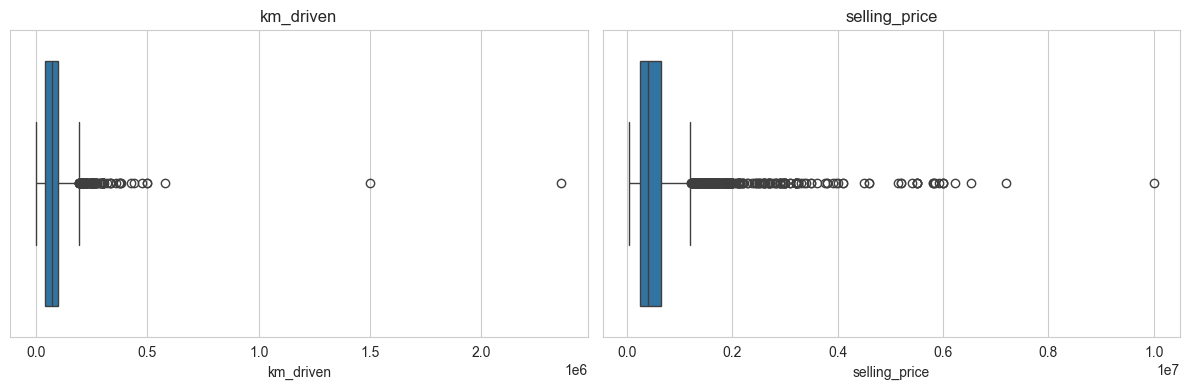

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["km_driven"], ax=axes[0])
sns.boxplot(x=df["selling_price"], ax=axes[1])
axes[0].set_title("km_driven")
axes[1].set_title("selling_price")
plt.tight_layout()
plt.show()

In [ ]:
km_cap = df["km_driven"].quantile(0.99)
n_capped = (df["km_driven"] > km_cap).sum()
df["km_driven"] = df["km_driven"].clip(upper=km_cap)
print(f"Capped {n_capped} rows with km_driven above {km_cap:,.0f} km")

Capped 70 rows with km_driven above 239,863 km


## 4. Exploratory Data Analysis

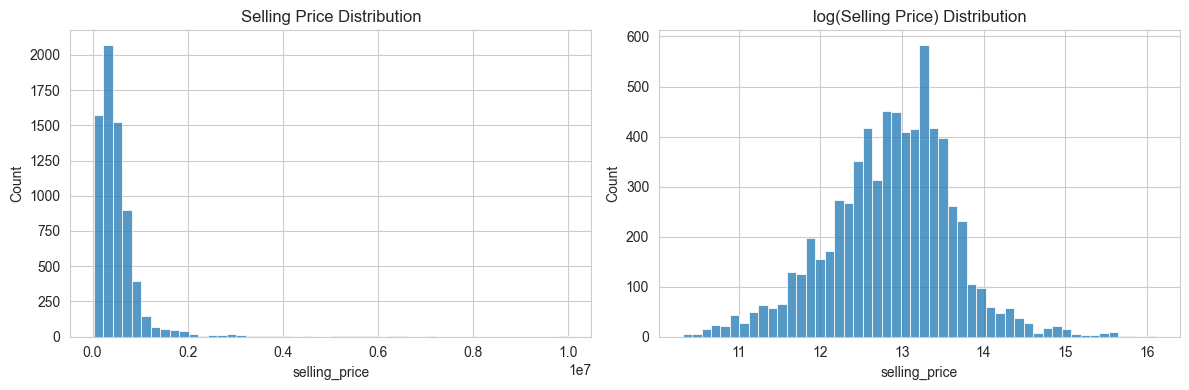

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["selling_price"], bins=50, ax=axes[0])
axes[0].set_title("Selling Price Distribution")

sns.histplot(np.log1p(df["selling_price"]), bins=50, ax=axes[1])
axes[1].set_title("log(Selling Price) Distribution")
plt.tight_layout()
plt.show()

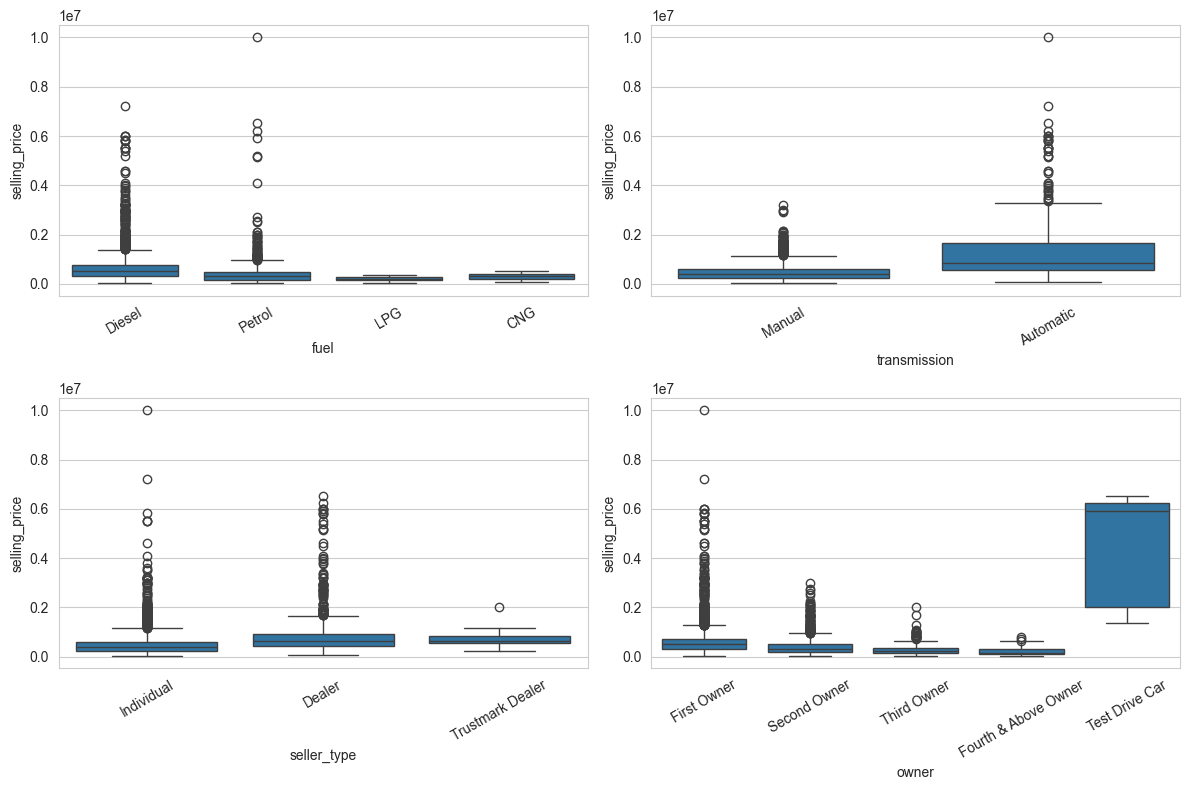

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(data=df, x="fuel", y="selling_price", ax=axes[0, 0])
sns.boxplot(data=df, x="transmission", y="selling_price", ax=axes[0, 1])
sns.boxplot(data=df, x="seller_type", y="selling_price", ax=axes[1, 0])
sns.boxplot(data=df, x="owner", y="selling_price", ax=axes[1, 1])
for ax in axes.flat:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

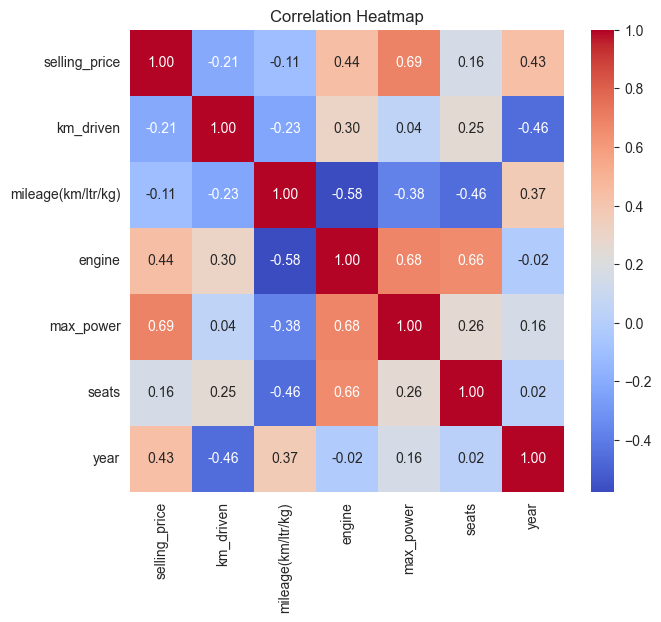

In [ ]:
numeric_cols = ["selling_price", "km_driven", "mileage(km/ltr/kg)", "engine", "max_power", "seats", "year"]
plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 5. Feature Engineering & Preprocessing

In [ ]:
# Extract brand from the car name, turn year into car age (more intuitive for the model)
df["brand"] = df["name"].str.split().str[0]
df["car_age"] = 2024 - df["year"]
df = df.drop(columns=["name", "year"])

X = df.drop(columns=["selling_price"])
y = df["selling_price"]

num_cols = ["km_driven", "mileage(km/ltr/kg)", "engine", "max_power", "seats", "car_age"]
cat_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(5540, 11) (1386, 11)


In [ ]:
categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

In [ ]:
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

## 6. Model 1 — XGBoost

In [ ]:
xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

# Small, sensible grid — keeps runtime reasonable while still doing real tuning
xgb_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
}

xgb_search = GridSearchCV(
    xgb_pipe, xgb_param_grid, cv=3,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
xgb_pred = xgb_search.predict(X_test)
xgb_best = xgb_search.best_estimator_

Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 400}


## 7. Model 2 — Linear Regression

In [ ]:
lr_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression()),
])

lr_param_grid = {
    "model__fit_intercept": [True, False]
}

lr_search = GridSearchCV(
    lr_pipe,
    lr_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

lr_search.fit(X_train, y_train)

print("Best params:", lr_search.best_params_)

lr_pred = lr_search.predict(X_test)

lr_best = lr_search.best_estimator_

Best params: {'model__fit_intercept': True}


## 8. Comparative Evaluation

In [ ]:
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, lr_pred),
    evaluate("XGBoost", y_test, xgb_pred),
])
results

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,6.406271e+10,253106.121714,132065.228197,0.707905
1,XGBoost,1.759060e+10,132629.558093,75538.945312,0.919795


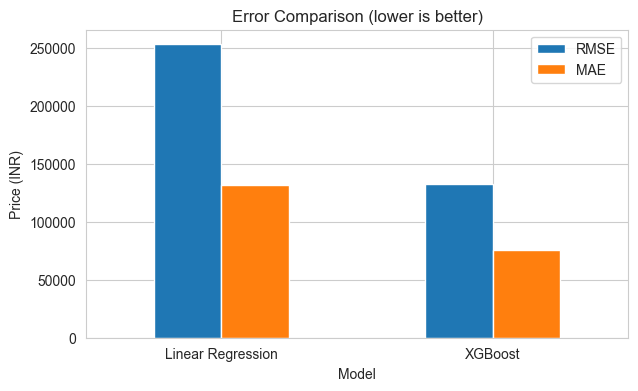

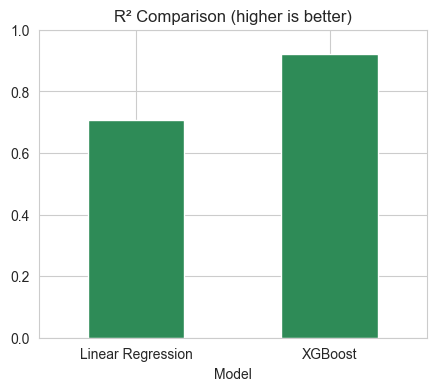

In [ ]:
results.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", figsize=(7, 4), rot=0)
plt.title("Error Comparison (lower is better)")
plt.ylabel("Price (INR)")
plt.show()

results.set_index("Model")[["R2"]].plot(kind="bar", figsize=(5, 4), rot=0, legend=False, color="seagreen")
plt.title("R² Comparison (higher is better)")
plt.ylim(0, 1)
plt.show()

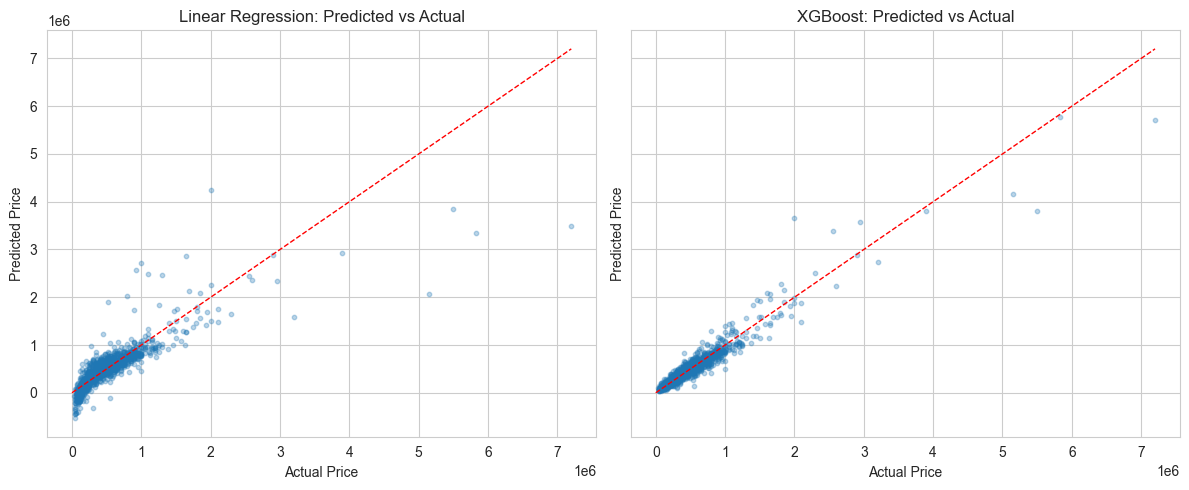

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, pred, title in zip(axes, [lr_pred, xgb_pred], ["Linear Regression", "XGBoost"]):
    ax.scatter(y_test, pred, alpha=0.3, s=10)
    lims = [0, y_test.max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(f"{title}: Predicted vs Actual")
plt.tight_layout()
plt.show()

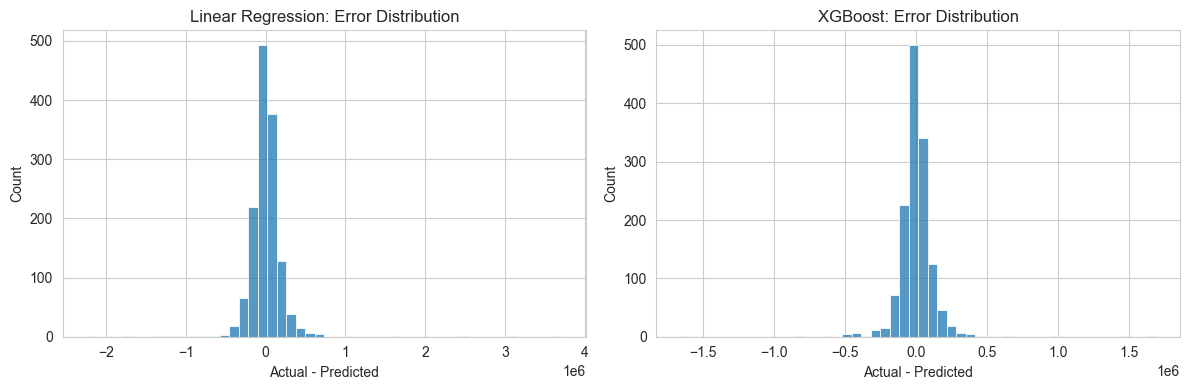

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(axes, [lr_pred, xgb_pred], ["Linear Regression", "XGBoost"]):
    errors = y_test - pred
    sns.histplot(errors, bins=50, ax=ax)
    ax.set_title(f"{title}: Error Distribution")
    ax.set_xlabel("Actual - Predicted")
plt.tight_layout()
plt.show()

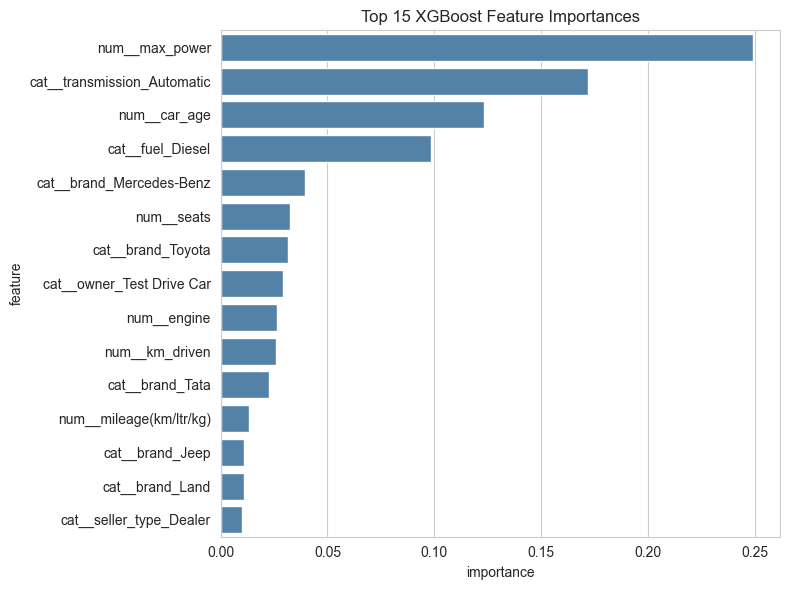

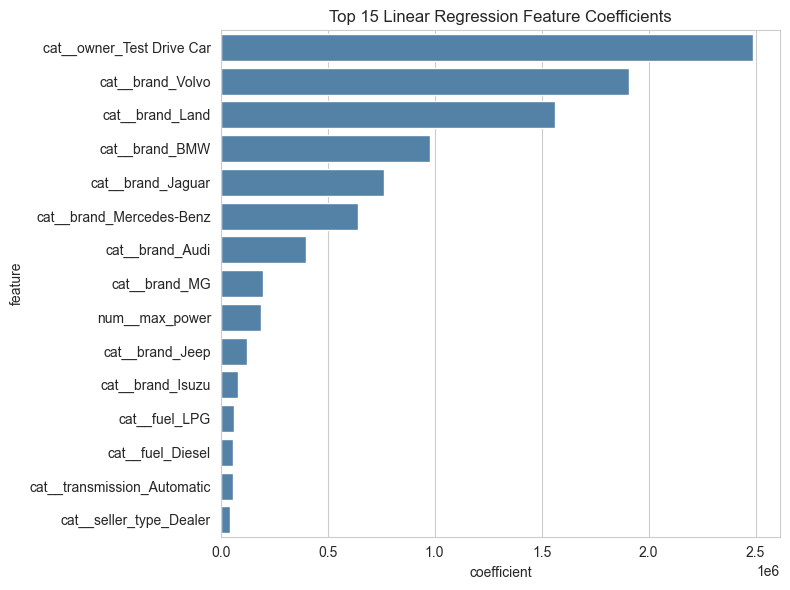

In [ ]:
# Feature importances for XGBoost
feature_names = xgb_best.named_steps["prep"].get_feature_names_out()
importances = xgb_best.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", color="steelblue")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# Feature importances for Linear Regression
feature_names = lr_best.named_steps["prep"].get_feature_names_out()
coefficients = lr_best.named_steps["model"].coef_

imp_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
imp_df = imp_df.sort_values("coefficient", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="coefficient", y="feature", color="steelblue")
plt.title("Top 15 Linear Regression Feature Coefficients")
plt.tight_layout()
plt.show()


## 9. Cross-Validation (more robust than a single train/test split)

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = {}
for name, pipe in [("Linear Regression", lr_pipe), ("XGBoost", xgb_search.best_estimator_)]:
    scores = cross_val_score(pipe, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_scores[name] = -scores
    print(f"{name}: RMSE = {-scores.mean():.0f} (+/- {scores.std():.0f}) across 5 folds")

Linear Regression: RMSE = 277256 (+/- 38587) across 5 folds
XGBoost: RMSE = 172105 (+/- 39392) across 5 folds


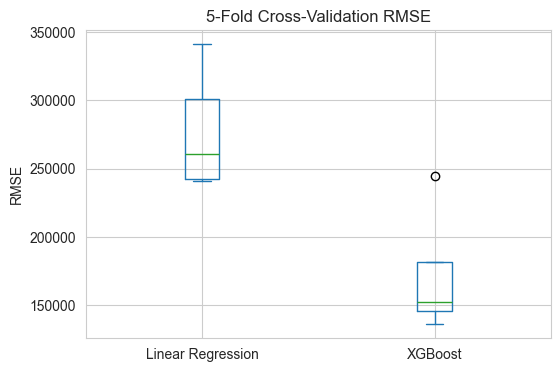

In [ ]:
cv_df = pd.DataFrame(cv_scores)
cv_df.plot(kind="box", figsize=(6, 4))
plt.ylabel("RMSE")
plt.title("5-Fold Cross-Validation RMSE")
plt.show()

## 10. Residual Analysis

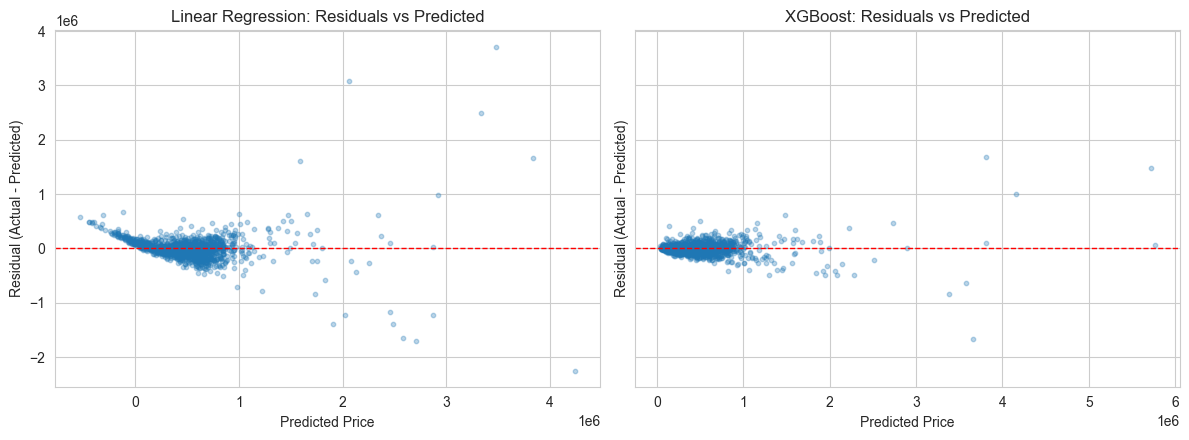

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, pred, title in zip(axes, [lr_pred, xgb_pred], ["Linear Regression", "XGBoost"]):
    residuals = y_test - pred
    ax.scatter(pred, residuals, alpha=0.3, s=10)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(f"{title}: Residuals vs Predicted")
plt.tight_layout()
plt.show()

## 11. Save the Best Model

In [ ]:
import joblib

joblib.dump(xgb_search.best_estimator_, "best_model_xgboost.joblib")
print("Saved best_model_xgboost.joblib")

Saved best_model_xgboost.joblib


## 12. Predict on a New Car

In [ ]:
def predict_price(model, **car):
    """Predict selling price for a single car. Pass the same fields as the
    training data, e.g.:
    predict_price(xgb_search.best_estimator_, km_driven=50000, mileage=18.0,
                   engine=1200.0, max_power=85.0, seats=5.0, fuel="Petrol",
                   seller_type="Individual", transmission="Manual",
                   owner="First Owner", brand="Maruti", car_age=5)
    """
    row = pd.DataFrame([{
        "km_driven": car["km_driven"],
        "mileage(km/ltr/kg)": car["mileage"],
        "engine": car["engine"],
        "max_power": car["max_power"],
        "seats": car["seats"],
        "fuel": car["fuel"],
        "seller_type": car["seller_type"],
        "transmission": car["transmission"],
        "owner": car["owner"],
        "brand": car["brand"],
        "car_age": car["car_age"],
    }])
    return model.predict(row)[0]


example_price = predict_price(
    xgb_search.best_estimator_,
    km_driven=50000, mileage=18.0, engine=1200.0, max_power=85.0, seats=5.0,
    fuel="Petrol", seller_type="Individual", transmission="Manual",
    owner="First Owner", brand="Maruti", car_age=5,
)
print(f"Predicted selling price: {example_price:,.0f}$")

Predicted selling price: 595,394$
